# BD PowerCast — Daily Load-Shedding Risk Prediction

## Objective

Build a date-based classification model that estimates the probability
of load shedding for a requested future date.

Application output:

- Load-Shedding Probability
- Risk Level: Low / Medium / High

The final Streamlit system will combine this model with the daily
electricity-demand forecasting models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import joblib
import json
import os

In [2]:
df = pd.read_csv(
    "../data/processed/PGCB_hourly_preprocessed_stage6_continuous.csv",
    parse_dates=["datetime"]
)

print("Dataset shape:", df.shape)

print(
    "Date range:",
    df["datetime"].min(),
    "→",
    df["datetime"].max()
)

Dataset shape: (89101, 61)
Date range: 2015-04-19 00:00:00 → 2025-06-17 12:00:00


In [3]:
df["load_shedding_event"] = (
    df["load_shedding"] > 0
).astype(int)

print(
    df["load_shedding_event"]
    .value_counts()
)

print(
    "\nHourly event rate:",
    f"{df['load_shedding_event'].mean() * 100:.2f}%"
)

load_shedding_event
0    74963
1    14138
Name: count, dtype: int64

Hourly event rate: 15.87%


prepare observed hourly rows

In [4]:
ls_source = df[
    df["row_observed"] == 1
].copy()

ls_source["date"] = (
    ls_source["datetime"].dt.normalize()
)

print(
    "Observed hourly rows:",
    len(ls_source)
)

Observed hourly rows: 88046


create daily load-shedding target

In [5]:
daily_ls = (
    ls_source
    .groupby("date")
    .agg(
        load_shedding_event=(
            "load_shedding_event",
            "max"
        ),

        load_shedding_hours=(
            "load_shedding_event",
            "sum"
        ),

        total_load_shedding=(
            "load_shedding",
            "sum"
        ),

        average_demand_mw=(
            "demand_mw_clean",
            "mean"
        ),

        peak_demand_mw=(
            "demand_mw_clean",
            "max"
        ),

        hourly_records=(
            "datetime",
            "count"
        )
    )
    .reset_index()
)

daily_ls.head()

,date,load_shedding_event,load_shedding_hours,total_load_shedding,average_demand_mw,peak_demand_mw,hourly_records
0,2015-04-19,0,0,0.0,4993.391304,6897.0,23
1,2015-04-20,0,0,0.0,5908.181818,6702.0,11
2,2015-04-21,0,0,0.0,6249.250000,7473.0,16
3,2015-04-22,0,0,0.0,4811.704545,6811.0,22
4,2015-04-23,0,0,0.0,4733.541667,6821.0,24


keep complete 24-hour days

In [6]:
daily_ls = daily_ls[
    daily_ls["hourly_records"] == 24
].copy()

daily_ls = daily_ls.reset_index(
    drop=True
)

print(
    "Complete days:",
    len(daily_ls)
)

print(
    "Date range:",
    daily_ls["date"].min(),
    "→",
    daily_ls["date"].max()
)

Complete days: 3465
Date range: 2015-04-23 00:00:00 → 2025-06-16 00:00:00


inspect daily class balance

In [7]:
class_counts = (
    daily_ls["load_shedding_event"]
    .value_counts()
    .sort_index()
)

class_percent = (
    daily_ls["load_shedding_event"]
    .value_counts(
        normalize=True
    )
    .sort_index()
    * 100
)

print("DAILY LOAD-SHEDDING DISTRIBUTION")
print("=" * 40)

print(
    "No load shedding:",
    class_counts.get(0, 0),
    f"({class_percent.get(0, 0):.2f}%)"
)

print(
    "Load shedding:",
    class_counts.get(1, 0),
    f"({class_percent.get(1, 0):.2f}%)"
)

DAILY LOAD-SHEDDING DISTRIBUTION
No load shedding: 2584 (74.57%)
Load shedding: 881 (25.43%)


inspect severity

In [8]:
positive_days = daily_ls[
    daily_ls["load_shedding_event"] == 1
]

print(
    "Average load-shedding hours "
    "on positive days:",
    positive_days[
        "load_shedding_hours"
    ].mean()
)

print(
    "Median load-shedding hours:",
    positive_days[
        "load_shedding_hours"
    ].median()
)

print(
    "Maximum load-shedding hours:",
    positive_days[
        "load_shedding_hours"
    ].max()
)

Average load-shedding hours on positive days: 15.42905788876277
Median load-shedding hours: 17.0
Maximum load-shedding hours: 24


annual event rate

In [9]:
daily_ls["year"] = (
    daily_ls["date"].dt.year
)

yearly_risk = (
    daily_ls
    .groupby("year")[
        "load_shedding_event"
    ]
    .mean()
    * 100
)

yearly_risk

year
2015     4.867257
2016     3.438395
2017     2.295082
2018     3.353659
2019     2.958580
2020     1.714286
2021     0.847458
2022    36.363636
2023    80.869565
2024    77.183099
2025    85.889571
Name: load_shedding_event, dtype: float64

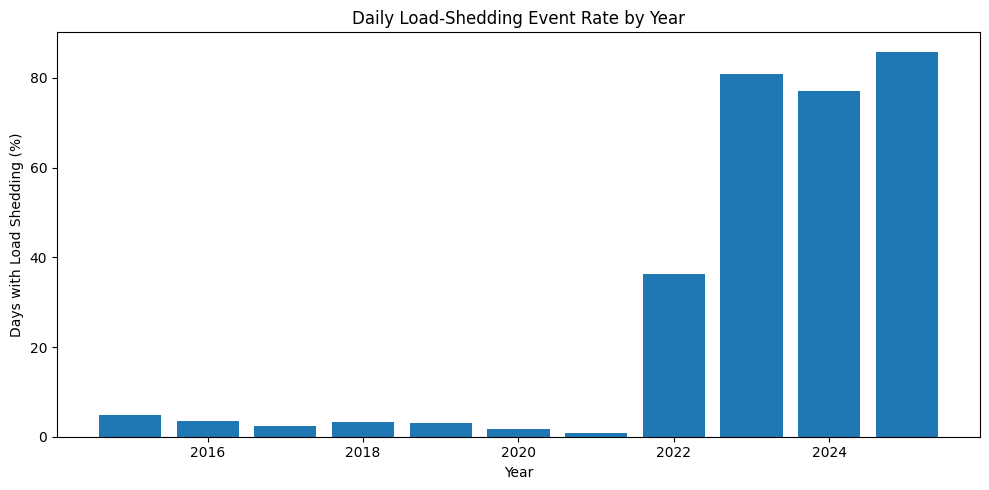

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    yearly_risk.index,
    yearly_risk.values
)

plt.xlabel("Year")
plt.ylabel(
    "Days with Load Shedding (%)"
)

plt.title(
    "Daily Load-Shedding Event Rate by Year"
)

plt.tight_layout()
plt.show()

create future-safe date features

In [11]:
daily_ls["month"] = daily_ls["date"].dt.month
daily_ls["day"] = daily_ls["date"].dt.day
daily_ls["day_of_week"] = daily_ls["date"].dt.dayofweek
daily_ls["day_of_year"] = daily_ls["date"].dt.dayofyear

daily_ls["is_friday"] = (
    daily_ls["day_of_week"] == 4
).astype(int)

daily_ls["is_weekend"] = (
    daily_ls["day_of_week"].isin([4, 5])
).astype(int)

reference_date_ls = daily_ls["date"].min()

daily_ls["days_since_start"] = (
    daily_ls["date"] - reference_date_ls
).dt.days

daily_ls["trend_years"] = (
    daily_ls["days_since_start"] / 365.25
)

print("Basic date features created.")

Basic date features created.


cyclic seasonal features

In [12]:
daily_ls["dow_sin"] = np.sin(
    2 * np.pi * daily_ls["day_of_week"] / 7
)

daily_ls["dow_cos"] = np.cos(
    2 * np.pi * daily_ls["day_of_week"] / 7
)

daily_ls["month_sin"] = np.sin(
    2 * np.pi * (daily_ls["month"] - 1) / 12
)

daily_ls["month_cos"] = np.cos(
    2 * np.pi * (daily_ls["month"] - 1) / 12
)

daily_ls["year_sin"] = np.sin(
    2 * np.pi * daily_ls["day_of_year"] / 365.25
)

daily_ls["year_cos"] = np.cos(
    2 * np.pi * daily_ls["day_of_year"] / 365.25
)

daily_ls["year_sin_2"] = np.sin(
    4 * np.pi * daily_ls["day_of_year"] / 365.25
)

daily_ls["year_cos_2"] = np.cos(
    4 * np.pi * daily_ls["day_of_year"] / 365.25
)

print("Seasonal features created.")

Seasonal features created.


feature list

In [13]:
ls_features = [
    "trend_years",

    "is_friday",
    "is_weekend",

    "dow_sin",
    "dow_cos",

    "month_sin",
    "month_cos",

    "year_sin",
    "year_cos",

    "year_sin_2",
    "year_cos_2"
]

ls_target = "load_shedding_event"

print("Features:", len(ls_features))

Features: 11


chronological split

In [14]:
train_ls = daily_ls[
    daily_ls["date"] < "2023-01-01"
].copy()

val_ls = daily_ls[
    (daily_ls["date"] >= "2023-01-01") &
    (daily_ls["date"] < "2024-01-01")
].copy()

test_ls = daily_ls[
    daily_ls["date"] >= "2024-01-01"
].copy()

print("Train:", len(train_ls))
print("Validation:", len(val_ls))
print("Test:", len(test_ls))

print("\nPositive rates")

print(
    "Train:",
    f"{train_ls[ls_target].mean()*100:.2f}%"
)

print(
    "Validation:",
    f"{val_ls[ls_target].mean()*100:.2f}%"
)

print(
    "Test:",
    f"{test_ls[ls_target].mean()*100:.2f}%"
)

Train: 2602
Validation: 345
Test: 518

Positive rates
Train: 7.23%
Validation: 80.87%
Test: 79.92%


Logistic Regression baseline

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_ls = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

logistic_ls.fit(
    train_ls[ls_features],
    train_ls[ls_target]
)

val_prob_logistic = logistic_ls.predict_proba(
    val_ls[ls_features]
)[:, 1]

evaluate probability quality

In [16]:
val_pred_logistic = (
    val_prob_logistic >= 0.5
).astype(int)

logistic_metrics = {
    "Accuracy": accuracy_score(
        val_ls[ls_target],
        val_pred_logistic
    ),

    "Precision": precision_score(
        val_ls[ls_target],
        val_pred_logistic,
        zero_division=0
    ),

    "Recall": recall_score(
        val_ls[ls_target],
        val_pred_logistic,
        zero_division=0
    ),

    "F1": f1_score(
        val_ls[ls_target],
        val_pred_logistic,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        val_ls[ls_target],
        val_prob_logistic
    ),

    "PR_AUC": average_precision_score(
        val_ls[ls_target],
        val_prob_logistic
    )
}

print("LOGISTIC REGRESSION — VALIDATION")
print("=" * 40)

for metric, value in logistic_metrics.items():
    print(
        f"{metric:10s}: {value:.4f}"
    )

LOGISTIC REGRESSION — VALIDATION
Accuracy  : 0.7304
Precision : 0.7943
Recall    : 0.8996
F1        : 0.8437
ROC_AUC   : 0.5250
PR_AUC    : 0.8594


Random Forest classifier

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_ls = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_ls.fit(
    train_ls[ls_features],
    train_ls[ls_target]
)

val_prob_rf = rf_ls.predict_proba(
    val_ls[ls_features]
)[:, 1]

val_pred_rf = (
    val_prob_rf >= 0.5
).astype(int)

In [18]:
rf_metrics = {
    "Accuracy": accuracy_score(
        val_ls[ls_target],
        val_pred_rf
    ),

    "Precision": precision_score(
        val_ls[ls_target],
        val_pred_rf,
        zero_division=0
    ),

    "Recall": recall_score(
        val_ls[ls_target],
        val_pred_rf,
        zero_division=0
    ),

    "F1": f1_score(
        val_ls[ls_target],
        val_pred_rf,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        val_ls[ls_target],
        val_prob_rf
    ),

    "PR_AUC": average_precision_score(
        val_ls[ls_target],
        val_prob_rf
    )
}

print("RANDOM FOREST — VALIDATION")
print("=" * 40)

for metric, value in rf_metrics.items():
    print(
        f"{metric:10s}: {value:.4f}"
    )

RANDOM FOREST — VALIDATION
Accuracy  : 0.4667
Precision : 0.8519
Recall    : 0.4122
F1        : 0.5556
ROC_AUC   : 0.6217
PR_AUC    : 0.8863


inspect yearly load-shedding rates

In [19]:
yearly_summary = (
    daily_ls
    .groupby(
        daily_ls["date"].dt.year
    )
    .agg(
        days=("load_shedding_event", "size"),
        positive_days=("load_shedding_event", "sum"),
        positive_rate=("load_shedding_event", "mean"),
        avg_ls_hours=("load_shedding_hours", "mean"),
        avg_ls_amount=("total_load_shedding", "mean")
    )
)

yearly_summary["positive_rate"] *= 100

yearly_summary

,days,positive_days,positive_rate,avg_ls_hours,avg_ls_amount
date,,,,,
2015,226,11,4.867257,0.079646,25.765487
2016,349,12,3.438395,0.085960,17.002865
2017,305,7,2.295082,0.022951,435.518033
2018,328,11,3.353659,0.033537,147.475610
2019,338,10,2.958580,0.029586,7.002959
2020,350,6,1.714286,0.017143,46.554286
2021,354,3,0.847458,0.008475,1.703390
2022,352,128,36.363636,6.315341,5261.619318
2023,345,279,80.869565,13.553623,7378.304348


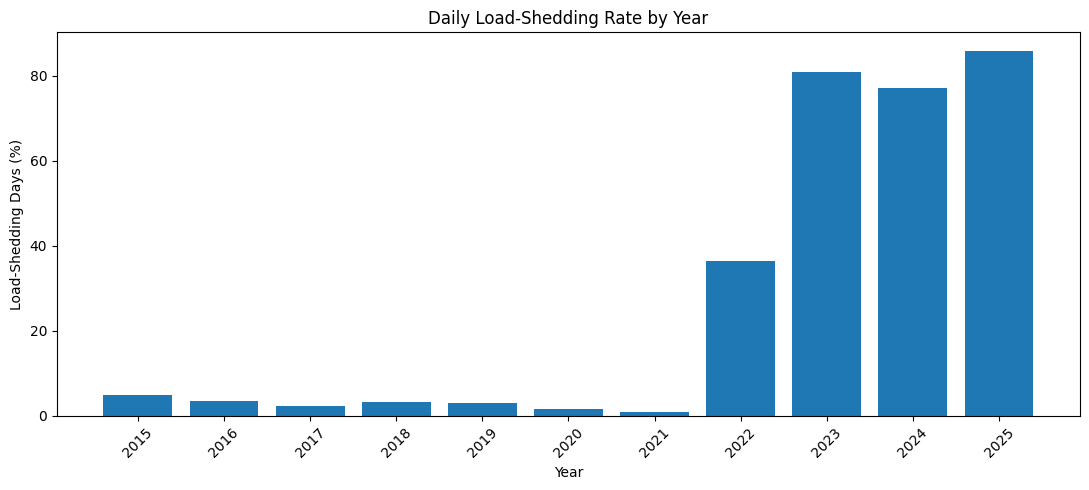

In [20]:
plt.figure(figsize=(11, 5))

plt.bar(
    yearly_summary.index,
    yearly_summary["positive_rate"]
)

plt.xlabel("Year")
plt.ylabel("Load-Shedding Days (%)")

plt.title(
    "Daily Load-Shedding Rate by Year"
)

plt.xticks(
    yearly_summary.index,
    rotation=45
)

plt.tight_layout()
plt.show()

In [21]:
yearly_summary = (
    daily_ls
    .groupby(
        daily_ls["date"].dt.year
    )
    .agg(
        days=(
            "load_shedding_event",
            "size"
        ),

        positive_days=(
            "load_shedding_event",
            "sum"
        ),

        positive_rate=(
            "load_shedding_event",
            "mean"
        ),

        avg_ls_hours=(
            "load_shedding_hours",
            "mean"
        ),

        avg_ls_amount=(
            "total_load_shedding",
            "mean"
        )
    )
)

yearly_summary["positive_rate"] = (
    yearly_summary["positive_rate"] * 100
)

display(yearly_summary)

,days,positive_days,positive_rate,avg_ls_hours,avg_ls_amount
date,,,,,
2015,226,11,4.867257,0.079646,25.765487
2016,349,12,3.438395,0.085960,17.002865
2017,305,7,2.295082,0.022951,435.518033
2018,328,11,3.353659,0.033537,147.475610
2019,338,10,2.958580,0.029586,7.002959
2020,350,6,1.714286,0.017143,46.554286
2021,354,3,0.847458,0.008475,1.703390
2022,352,128,36.363636,6.315341,5261.619318
2023,345,279,80.869565,13.553623,7378.304348


recent-regime split

In [22]:
recent_ls = daily_ls[
    daily_ls["date"] >= "2022-01-01"
].copy()

train_ls_recent = recent_ls[
    recent_ls["date"] < "2024-01-01"
].copy()

val_ls_recent = recent_ls[
    (recent_ls["date"] >= "2024-01-01") &
    (recent_ls["date"] < "2025-01-01")
].copy()

test_ls_recent = recent_ls[
    recent_ls["date"] >= "2025-01-01"
].copy()

print("RECENT-REGIME SPLIT")
print("=" * 35)

print("Train:", len(train_ls_recent))
print("Validation:", len(val_ls_recent))
print("Test:", len(test_ls_recent))

print("\nPositive rates:")

print(
    "Train:",
    f"{train_ls_recent[ls_target].mean()*100:.2f}%"
)

print(
    "Validation:",
    f"{val_ls_recent[ls_target].mean()*100:.2f}%"
)

print(
    "Test:",
    f"{test_ls_recent[ls_target].mean()*100:.2f}%"
)

RECENT-REGIME SPLIT
Train: 697
Validation: 355
Test: 163

Positive rates:
Train: 58.39%
Validation: 77.18%
Test: 85.89%


In [23]:
logistic_recent = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=42
        )
    )
])

logistic_recent.fit(
    train_ls_recent[ls_features],
    train_ls_recent[ls_target]
)

val_prob_recent = logistic_recent.predict_proba(
    val_ls_recent[ls_features]
)[:, 1]

val_pred_recent = (
    val_prob_recent >= 0.5
).astype(int)

In [24]:
recent_metrics = {
    "Accuracy": accuracy_score(
        val_ls_recent[ls_target],
        val_pred_recent
    ),

    "Precision": precision_score(
        val_ls_recent[ls_target],
        val_pred_recent,
        zero_division=0
    ),

    "Recall": recall_score(
        val_ls_recent[ls_target],
        val_pred_recent,
        zero_division=0
    ),

    "F1": f1_score(
        val_ls_recent[ls_target],
        val_pred_recent,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        val_ls_recent[ls_target],
        val_prob_recent
    ),

    "PR_AUC": average_precision_score(
        val_ls_recent[ls_target],
        val_prob_recent
    )
}

print("RECENT-REGIME LOGISTIC — VALIDATION")
print("=" * 45)

for metric, value in recent_metrics.items():
    print(f"{metric:10s}: {value:.4f}")

RECENT-REGIME LOGISTIC — VALIDATION
Accuracy  : 0.7718
Precision : 0.7718
Recall    : 1.0000
F1        : 0.8712
ROC_AUC   : 0.8469
PR_AUC    : 0.9486


test several probability thresholds

In [25]:
threshold_results = []

for threshold in np.arange(
    0.30,
    0.71,
    0.05
):

    pred = (
        val_prob_recent >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,

        "Precision": precision_score(
            val_ls_recent[ls_target],
            pred,
            zero_division=0
        ),

        "Recall": recall_score(
            val_ls_recent[ls_target],
            pred,
            zero_division=0
        ),

        "F1": f1_score(
            val_ls_recent[ls_target],
            pred,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,Threshold,Precision,Recall,F1
0,0.30,0.771831,1.0,0.871224
1,0.35,0.771831,1.0,0.871224
2,0.40,0.771831,1.0,0.871224
3,0.45,0.771831,1.0,0.871224
4,0.50,0.771831,1.0,0.871224
5,0.55,0.771831,1.0,0.871224
6,0.60,0.776204,1.0,0.874003
7,0.65,0.780627,1.0,0.876800
8,0.70,0.791908,1.0,0.883871


In [26]:
best_threshold_row = (
    threshold_results.loc[
        threshold_results["F1"].idxmax()
    ]
)

best_threshold = (
    best_threshold_row["Threshold"]
)

print(
    "Best threshold:",
    round(best_threshold, 2)
)

print(
    "Validation F1:",
    round(
        best_threshold_row["F1"],
        4
    )
)

Best threshold: 0.7
Validation F1: 0.8839


inspect validation at the selected threshold

In [27]:
selected_threshold = 0.70

val_pred_selected = (
    val_prob_recent >= selected_threshold
).astype(int)

print("VALIDATION @ THRESHOLD 0.70")
print("=" * 40)

print(
    "Precision:",
    f"{precision_score(val_ls_recent[ls_target], val_pred_selected):.4f}"
)

print(
    "Recall   :",
    f"{recall_score(val_ls_recent[ls_target], val_pred_selected):.4f}"
)

print(
    "F1       :",
    f"{f1_score(val_ls_recent[ls_target], val_pred_selected):.4f}"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        val_ls_recent[ls_target],
        val_pred_selected
    )
)

VALIDATION @ THRESHOLD 0.70
Precision: 0.7919
Recall   : 1.0000
F1       : 0.8839

Confusion Matrix:
[[  9  72]
 [  0 274]]


final test

In [28]:
test_prob_recent = logistic_recent.predict_proba(
    test_ls_recent[ls_features]
)[:, 1]

test_pred_recent = (
    test_prob_recent >= selected_threshold
).astype(int)

test_accuracy = accuracy_score(
    test_ls_recent[ls_target],
    test_pred_recent
)

test_precision = precision_score(
    test_ls_recent[ls_target],
    test_pred_recent,
    zero_division=0
)

test_recall = recall_score(
    test_ls_recent[ls_target],
    test_pred_recent,
    zero_division=0
)

test_f1 = f1_score(
    test_ls_recent[ls_target],
    test_pred_recent,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    test_ls_recent[ls_target],
    test_prob_recent
)

test_pr_auc = average_precision_score(
    test_ls_recent[ls_target],
    test_prob_recent
)

print("LOAD-SHEDDING MODEL — FINAL TEST")
print("=" * 42)

print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1        : {test_f1:.4f}")
print(f"ROC-AUC   : {test_roc_auc:.4f}")
print(f"PR-AUC    : {test_pr_auc:.4f}")

LOAD-SHEDDING MODEL — FINAL TEST
Accuracy  : 0.8589
Precision : 0.8589
Recall    : 1.0000
F1        : 0.9241
ROC-AUC   : 0.5168
PR-AUC    : 0.8534


confusion matrix

In [29]:
print(
    confusion_matrix(
        test_ls_recent[ls_target],
        test_pred_recent
    )
)

[[  0  23]
 [  0 140]]


create monthly risk table

In [30]:
# Use recent load-shedding regime only
recent_risk_data = daily_ls[
    daily_ls["date"] >= "2023-01-01"
].copy()

recent_risk_data["month"] = (
    recent_risk_data["date"].dt.month
)

monthly_risk = (
    recent_risk_data
    .groupby("month")
    .agg(
        total_days=(
            "load_shedding_event",
            "count"
        ),

        load_shedding_days=(
            "load_shedding_event",
            "sum"
        ),

        risk_score=(
            "load_shedding_event",
            "mean"
        )
    )
    .reset_index()
)

monthly_risk["risk_score"] *= 100

month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

monthly_risk["month_name"] = (
    monthly_risk["month"]
    .map(month_names)
)

monthly_risk = monthly_risk[
    [
        "month",
        "month_name",
        "total_days",
        "load_shedding_days",
        "risk_score"
    ]
]

monthly_risk

,month,month_name,total_days,load_shedding_days,risk_score
0,1,January,90,58,64.444444
1,2,February,79,75,94.936709
2,3,March,90,76,84.444444
3,4,April,87,79,90.804598
4,5,May,89,83,93.258427
5,6,June,75,67,89.333333
6,7,July,58,58,100.000000
7,8,August,60,59,98.333333
8,9,September,58,58,100.000000
9,10,October,60,53,88.333333


assign Low / Medium / High risk

In [31]:
def risk_level(score):

    if score < 40:
        return "Low"

    elif score < 70:
        return "Medium"

    else:
        return "High"


monthly_risk["risk_level"] = (
    monthly_risk["risk_score"]
    .apply(risk_level)
)

monthly_risk

,month,month_name,total_days,load_shedding_days,risk_score,risk_level
0,1,January,90,58,64.444444,Medium
1,2,February,79,75,94.936709,High
2,3,March,90,76,84.444444,High
3,4,April,87,79,90.804598,High
4,5,May,89,83,93.258427,High
5,6,June,75,67,89.333333,High
6,7,July,58,58,100.000000,High
7,8,August,60,59,98.333333,High
8,9,September,58,58,100.000000,High
9,10,October,60,53,88.333333,High


In [32]:
import os

os.makedirs("../models", exist_ok=True)

monthly_risk.to_csv(
    "../models/load_shedding_monthly_risk.csv",
    index=False
)

print(
    "Load-shedding risk table saved."
)

Load-shedding risk table saved.


application function

In [33]:
def get_load_shedding_risk(
    input_date
):

    date = pd.Timestamp(
        input_date
    )

    month = date.month

    row = monthly_risk[
        monthly_risk["month"] == month
    ].iloc[0]

    return {
        "date": str(date.date()),

        "risk_score": round(
            float(row["risk_score"]),
            2
        ),

        "risk_level":
            row["risk_level"],

        "basis":
            "Historical monthly load-shedding rate (2023-2025)"
    }

In [34]:
risk = get_load_shedding_risk(
    "2026-08-10"
)

risk

{'date': '2026-08-10',
 'risk_score': 98.33,
 'risk_level': 'High',
 'basis': 'Historical monthly load-shedding rate (2023-2025)'}

In [43]:
get_load_shedding_risk("2025-12-30")

{'date': '2025-12-30',
 'risk_score': 5.08,
 'risk_level': 'Low',
 'basis': 'Historical monthly load-shedding rate (2023-2025)'}